In [1]:
""" Chapter 03: Classification """

# As we know, the most common supervised learning tasks are regression (Predicting values) and Classification (Predicting class)

""" 1. MNIST """
# The "MNIST" dataset is a set of 70,000 small images of digits handwritten by high school students and employees of the US Census Bureau
# "Hello, World!" of the Machine Learning

# 3.1: Fetches the MNIST dataset from OpenML.org
from sklearn.datasets import fetch_openml

mnist = fetch_openml('mnist_784', as_frame=False)

# fetch_openml() to download real-life datasets,
# load_openml() to load small toy datasets bundled with Scikit-Learn,
# make_openml() to generate fake datasets, and useful for tests.

# The datasets usually returns as an (X, y) tuple containing the input data and the targets both as NumPy arrays.

In [2]:
# DESCR = A description of the dataset
# data = The input data, usually as a 2D NumPy array
# target = The labels usually as a 1D NumPY array

# The MNIST dataset contains images, and DataFrame aren't ideal for that, so it's preferable to set as_frame=False to get the data as NumPy array

X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784))

In [3]:
X.shape

(70000, 784)

In [4]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype=object)

In [5]:
y.shape

(70000,)

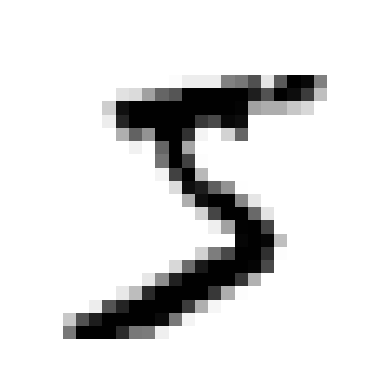

In [6]:
# There are 70,000 images, and each image has 784 features.
# 28 X 28 pixels and each feature simply represents one pixel's intensity. from 0 white to 255 black
# We use cmap="binary" to get a grayscale color map where 0 is white and 255 is black.

import matplotlib.pyplot as plt

def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")

some_digit = X[0]
plot_digit(some_digit)
plt.show()

In [7]:
# You noticed it's looks like a 5? indeed!
y[0]

'5'

In [8]:
# You should always create a test set and set it aside before inspecting the data closely.
# fetch_openml() is actually already split into a training set (the first 60,000 images) and a test set (the last 10,000 images)

X_train, X_test, y_train, y_test = X[:60000], X[60000], y[:60000], y[60000:]

# Some learning algorithms are sensitive to the order of the training instances, and they perform poorly if they get many similar instances in a row
# Shuffling the dataset ensures that this won't happen.

In [9]:
""" 2. Training a Binary Classifier """

# The number 5 or The "5-detector" will be an example of a binary classifier
# Capable of distinguishing betwenn just 2 classes, 5 and non-5
# Create the target vectors for this classification task:

y_train_5 = (y_train == '5') # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

In [10]:
# Start with a "stochastic gradient descent (SGD or stochastic GD)" classifier, using Scikit-Learn's SGDClassifier class
# SGD deals with training instances independentlly , one at a time, which also makes SGD well suited for an online learning

# 3.2: Create an SGDClassifier and train it on the whole training set:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

# use it to detect image of the number 5:
sgd_clf.predict([some_digit])

array([ True])

In [11]:
""" 3. Performance Measures """

""" Measuring Accuracy Using Cross-Validation """

# The "cross_val_score()" function to evaluate our SGDClassifier model, using k-fold cross-validation with 3 fold,
# k-fold cross-validation means splitting the training set into k folds (in this case, 3),
# then training the model k times holding out a different fold each time for evaluation

from sklearn.model_selection import cross_val_score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.95035, 0.96035, 0.9604 ])

In [12]:
# 95% looks decents
# check out a dummy classifier that just classfiers every single image in the most frequent class, which is this case is the nagative class
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # Prints False: no 5s detected

False


In [13]:
# Find out the model accuracy:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

In [14]:
# 90% accuracy
# Only about 10% of the images are 5s, so if you always guess that an image is not a 5, you will be right about 90% of the time!

# That's why "accuracy" not preferred performance meansure for classifier.
# Especially, when you dealing with skewed datasets

In [15]:
# Implementing Cross-Validation
# you can implement cross-validation yourself
# Using Scikit-Learn's cross_val_score()
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3) # add shuffle=True if the dataset is not ready to shuffled.

for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

    # The StratifiedKFold class performs stratified sampling and produce folds that contain a representative ratio of each class.
    # trains that clone on the training folds, and makes prediction on the test folds,
    # counts the number of correct predictions and outputs the ratio of correct prediction.

0.95035
0.96035
0.9604


In [16]:
""" 4. Confusion Matrices """

# To count the number of times instances of class A are classified as class B, for all A/B pairs.
# Ex. If you wanna know the number of times the classifier confused images of 8s with 0s.
# You would look at row #8 column #0 of the confusion matrix.

# To compute the confusion matrix, you first need to have a set of prediction so that they can be compared to the actual targets.
# or use the cross_val_predict()

from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [17]:
# cross_val_predict() performs k-fold cross-validation but instead of returning the evaluation scores,
# it returns the prediction made on each test fold.
# you get a out-of-sample prediction for each instance in the training set

from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_train_5, y_train_pred)
cm

array([[53892,   687],
       [ 1891,  3530]])

In [18]:
# Each row in a confusion matrix represents an 'actual class', while each column represents a 'predicted class'
# A perfect classifier would only have true positives and true negatives so its confusion matrix would have non-zero values only on its main diagonal

y_train_perfect_predictions = y_train_5 # Pretend we reached perfection
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

In [19]:
# The confusion matrix gives you a lot of information but sometimes you may prefer a more concise metric.

# Precision = TP / TP + FP
# TP is the number of true postitives, and FP is the number of false positives

# Recall = TP / TP + FN 
# sensitivity or the true positive rate (TPR)
# The ratio of positive instances athat are correctly detected by the classifier
# FN = the false negatives

In [20]:
""" 5. Precision and Recall """
# You can use it on Scikit-Learn

from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred) # == 3530 / (687 + 3530)

0.8370879772350012

In [21]:
recall_score(y_train_5, y_train_pred) # == 3530 / (1891 + 3530)

0.6511713705958311

In [22]:
# It is often conveninet to combine precision and recall into a single metric called the f1 score,
# especially when you need a single metric to compare 2 classifiers.
# The F1 score is the harmonic mean of precision and recall

# The harmonic mean gives much more weight to low values.

# F1 Score = (2 / (1 / Precision) + (1 / Recall)) = (2 * Precision * Recall / Precision + Recall) = (TP / TP + (FN + FP / 2))

from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

In [23]:
# The F1 score favors classifiers that have similar precision and recall
# In some contexts you mostly care about precision and in other contexts you really care about recall.
# Increasing precision reduces recall and vice versa. This is called the "precision/recall trade-off"

In [24]:
""" The Precision/Recall Trade Off """

# For each instance, it computes a score based on a decision function.
# If that score is greater than a threshold, it assigns the instance to positive class; otherwise it assigns it to the negative class
# The higher the threshold, the lower the recall, but (in general) the higher the precision.

# Scikit-Learn does not let you set the threshold directly, but it does give you access to the decision scores that it uses to make prediction.
# decision_function() = returns a score for each instance and the use any threshold you want to make predictions

y_scores = sgd_clf.decision_function([some_digit])
y_scores

array([2164.22030239])

In [25]:
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [26]:
# The SGDClassifer uses a threshold equal to 0, so the preceding code returns the same result as the predict() method
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [27]:
# This is confirms that raising the threshold decrease recall.

# Use the cross_val_predict() function to get the scores of all instances in the training set but this time
# specify that you want to return decision scores instead of prediction:

y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3, method="decision_function")

In [28]:
# Use the precision_recall_curve() function to compute precision and recall for all possible thresholds.
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

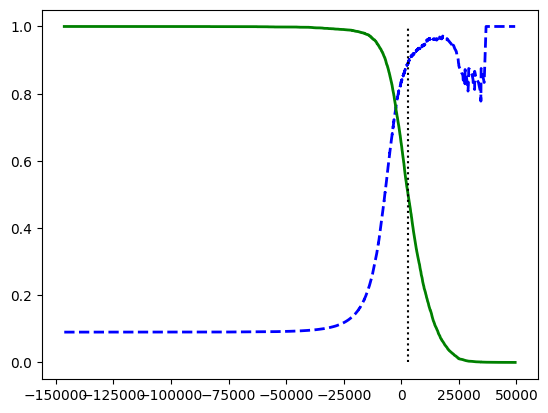

In [29]:
# Use Matplotlib to plot precision and recall as functions of the threshold value
import matplotlib.pyplot as plt
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")
[...]
plt.show()


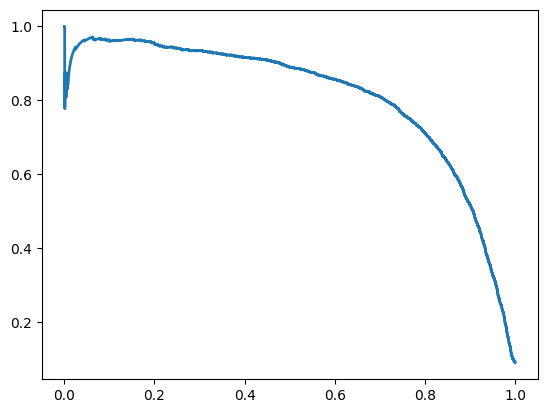

In [30]:
# The precision may sometimes go down when you raise the threshold.

# Plot precision directly against recall

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")
[...]
plt.show()

In [31]:
# You can see that precision really starts to fall sharply at around 80% recall.
# The choice depends on your project.

# You might aims for a 90%
# For this, you can use the NumPy array's argmax() method. This returns the first index of the maximum value.

idx_for_90_precision = (precisions >= 0.90).argmax()
threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.019499144183)

In [32]:
# Instead of calling the classifier's predict() method, run this code:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

# Check the prediction's precision and recall.
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [33]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

In [34]:
# Nice. Now you have a 90% precision classifier.
# Just set a high enough threshold, and you're done.

# Not so fast-a high precision classifier is not very useful if its recall is too low.
# If someone ask you "Let's reach 99% precision." you should ask "At what recall?"

<function matplotlib.pyplot.show(close=None, block=None)>

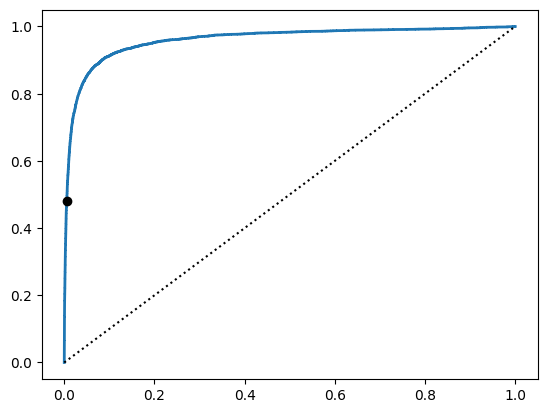

In [35]:
""" The ROC Curve """

# ROC = The receiver operating characteristic (ROC)
# It very similar to the precision/recall curve.
# The ROC curve plots the true positive rate against the false positive rate (FPR)
# The FPR = ratio of negative instances that are incorrectly classified as positive.
# It is equal to 1 the trur negative rate (TNR) which is the raio of negative instances that are correctly classified as negative

# To plot the ROC curve, use the roc_curve() functions

from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

# plot the FPR against the TPR using Matplotlib

idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")
[...] # add labels, grid, legend, arrow, and text
plt.show

In [36]:
# The higher the recall (TPR) the more false positives (FPR) the classifier produces.
# The dotted line represents the ROC curve of a purely random classifier.
# A good classifier stays as far away from that line as possible.

# AUC = Area under the curve
# A perfect classifier will have a ROC AUC equal to 1

from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

0.9604938554008616

In [37]:
# You should prefer the PR curve whenever the postive. class is rare or when you care more about the false positives than the false negatives.

# Let's now create a RanDonForestClassifier, whose PR curve and F1 score we can compare to those of the SGDClassifier:

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_predict

forest_clf = RandomForestClassifier(random_state=42)

# The precision_recall_curve() function expects labels and scores for each instance,
# So we need to train the random forest classifier and make it assign a score to each instance.

# The precision_recall_curve() function expects labels and scores for each instance,
# So we need to train the random forest classifier and make it assign a score to each instance.

# It has a predict_prob() method that returns estimated class probabilities for each instance.
# We can call the cross_val_predict() function to train the RanddomForestClassifier using cross-validation and make it predict class probabilities

y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3, method="predict_proba")

In [38]:
# Let's look at th estimated class probabilities for the first 2 images

y_probas_forest[:2]

array([[0.11, 0.89],
       [0.98, 0.02]])

In [39]:
# The model predicts that the first image is positive with 89% probability,
# It predict that the second imahe is negative with 99% probability
# The estimated probabilities in each row add up to 100%

# These are "estimated probabilities" not actual probabilities.

# The second column contains the estimated probabilities for the positive class,
# pass to the precision_recall_curve()

y_scores_forest = y_probas_forest[:, 1]
precision_forest, recalls_forest, thresholds_forest = precision_recall_curve(y_train_5, y_scores_forest)

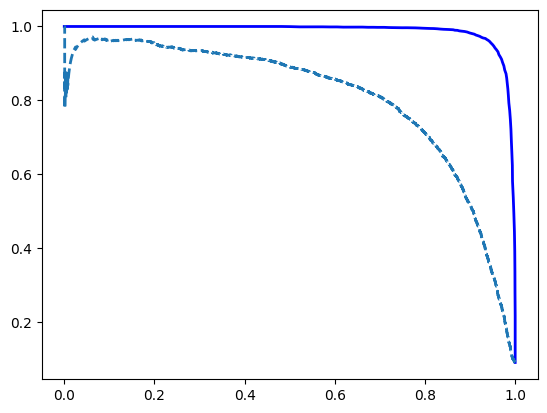

In [40]:
# Plot the first PR curve as well to see how they compare

plt.plot(recalls_forest, precision_forest, "b-", linewidth=2, label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")
[...] # Bueatify the figure: add labels, grid, and legend
plt.show()

In [41]:
# Its F1 score and ROC AUC score are also significantly better:

y_train_pred_forest = y_probas_forest[:, 1] >= 0.5 # Positive Proba => 50%
f1_score(y_train_5, y_train_pred_forest)

0.9270445185330457

In [42]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983296721818179

In [43]:
# Choose the appropriate metric for your task, evaluate your classifiers using cross-validation,
# Select the precision/recall trade off that fits your needs, and use several metrics and curves to compare various models.

In [44]:
""" Multiclass Classification """

# Multiclass classifiers (multinomial classifiers) can distinguish between more than 2 classes.
# One way to create a system that can classify the digit images into 10 classes (from 0 to 9) is to train 10 binary clasifiers.
# One for each digit (a 0-detector, a 1-detector, a 2-detector and so on)

# You select the class whose classifier outputs the highest score. = OVR, one-versus-the-rest
# OvA, one-versus-all

# Another strategy is to train a binary classifier for every pair of digits: one to distinguish 0s and 1s,
# another to distinguish 0s and 2s, another for 1s and 2s and so on. This is called the one-versus-one (OvO) strategy.

# N classes, train N * (N - 1) / 2 classifiers.

# The main advantage of OvO is that each classifier only needs to be trained on the part of the training set containing the 2 classes that it must distinguish

# For most binary classification algorithms, OvR is preferred.

from sklearn.svm import SVC

svm_clf = SVC(random_state=42)
svm_clf.fit(X_train[:2000], y_train[:2000]) # y_train, not y_train_5

# We trained the SVC using the original target classes from 0 to 9 (y_train), instead of the 5-versus-the-rest-target-classes (y_train_5)

svm_clf.predict([some_digit])

array(['5'], dtype=object)

In [45]:
# If you call the decision_function() method, you will see that it returns 10 scores per instance:
# one per class, Each class gets a score equal to the number of won duels plus or minus a small tweak.
# (max -+ -.33) to break ties, based on the classifiers scores.

some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores.round(2)

array([[ 3.79,  0.73,  6.06,  8.3 , -0.29,  9.3 ,  1.75,  2.77,  7.21,
         4.82]])

In [46]:
# The highest score is 9.3 and its conresponding to class 5:
class_id = some_digit_scores.argmax()
class_id

np.int64(5)

In [47]:
# When a classifier is trained, it stores the list of target classes in its classes_attribute, ordered by value.
# In general, You won't be so lucky; you will need to look up the class label like this:

svm_clf.classes_

array(['0', '1', '2', '3', '4', '5', '6', '7', '8', '9'], dtype=object)

In [48]:
svm_clf.classes_[class_id]

'5'

In [49]:
# If you want to force Scikit-Learn to use one-versus-one or one-versus-the-rest,
# you can use the OneVsOneClassifier or OneVsRestClassifier classes.

# Create an instance and pass a classifier to its constructor.

from sklearn.multiclass import OneVsRestClassifier

ovr_clf = OneVsRestClassifier(SVC(random_state=42))
ovr_clf.fit(X_train[:2000], y_train[:2000])

,"estimator estimator: estimator objectA regressor or a classifier that implements :term:`fit`.When a classifier is passed, :term:`decision_function` will be usedin priority and it will fallback to :term:`predict_proba` if it is notavailable.When a regressor is passed, :term:`predict` is used.",SVC(random_state=42)
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation: the `n_classes`one-vs-rest problems are computed in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: 0.20 `n_jobs` default changed from 1 to None",None
,"verbose verbose: int, default=0The verbosity level, if non zero, progress messages are printed.Below 50, the output is sent to stderr. Otherwise, the output is sentto stdout. The frequency of the messages increases with the verbositylevel, reporting all iterations at 10. See :class:`joblib.Parallel` formore details... versionadded:: 1.1",0
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001


In [50]:
# try to make aprediction and check the number of trained classifiers:

ovr_clf.predict([some_digit])

array(['5'], dtype='<U1')

In [51]:
len(ovr_clf.estimators_)

10

In [52]:
# Training an SGDClassifier on a multiclass dataset and using it to make a predictions 
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

In [53]:
# That's incorrect...

# since there are 10 classes, it trained 10 binary classifiers 
# The decision_function() method now returns one value per class.

sgd_clf.decision_function([some_digit]).round()

array([[-31893., -19048.,  -9531.,   1824., -22320.,  -1386., -26189.,
        -16148.,  -4604., -12051.]])

In [54]:
# The score are very negative, while class 3 has a score of +1,824, and class 5 is not too far behind at -1,386.
# You'll want to evaluate this classifier on more than one image.

# As usual, You can use the cross_val_score() function to evaluate the model:

cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87745, 0.85835, 0.8698 ])

In [55]:
# If you used a random classifier you would get 10% accuracy!
# this is not a bad score at all its get over 85.8%

# You can do better by scaling the inputs:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

# Set the max_iter so... the loop is not too long!
sgd_clf = SGDClassifier(max_iter=1000, tol=1e-3, random_state=42)

# Change to float32 for speed!
X_train_scaled = scaler.fit_transform(X_train.astype("float32"))

# Just the first 10,000
cross_val_score(sgd_clf, X_train_scaled[:10000], y_train[:10000], cv=3, scoring="accuracy", n_jobs=-1)

/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/Users/nattawut/Python-For-Ai/ScikitLearn-Keras-TensorFlow/ML_train/.venv/lib/python3.12/site-packages/sklearn/linear_model/_stochastic_gradient.py:733: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


array([0.89142172, 0.91029103, 0.88778878])

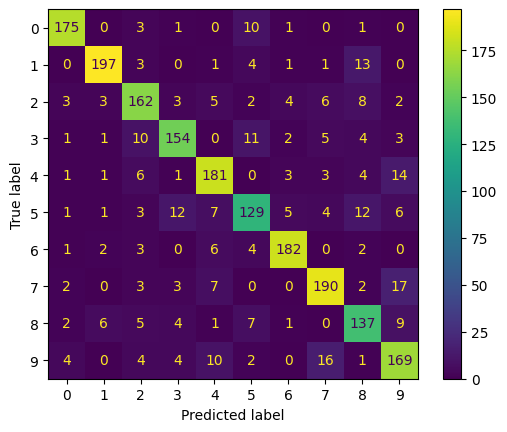

In [56]:
""" Error Analysis """

# You have a promising model and now looking to improve it
# One way to do this is to analyze the types of errors it makes.

# Look at the confusion matrix:
# using the cross_val_predict() function; then you can pass the labels and prediction to the confusion_matrix() function.
# just like we did earlier.

# BUT since there are now 10 classes instead of 2, the confusion matrix will contain a quite a lof of numbers, and it may be hard to read.

# confusion matrix is much easier to analyze:
# ConfusionMatrixDisplay.from_predictions()

import matplotlib.pyplot as plt
from sklearn.datasets import fetch_openml
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.model_selection import cross_val_predict
from sklearn.preprocessing import StandardScaler

# 1. get the MNIST
mnist = fetch_openml('mnist_784', version=1, as_frame=False)
X, y = mnist.data, mnist.target

# 2. Separate the train file / 2000 data for faster loader!
X_train, y_train = X[:2000], y[:2000]

# 3. Scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train.astype('float64'))

# 4. Train model SGD
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train_scaled, y_train)

# 5. Cross-Validation & Confusion Matrix
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

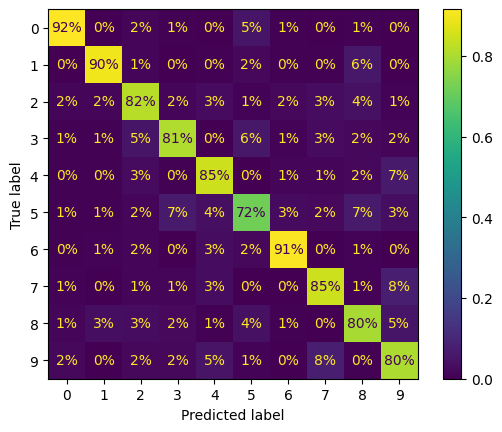

In [57]:
# The model made more Errors on 5s, or because there are fewer 5s in the dataset than the other digits.
# We can also specify the values_format=".0%" argument to show percentages with no decimals.

ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, normalize="true", values_format=".0%")
plt.show()

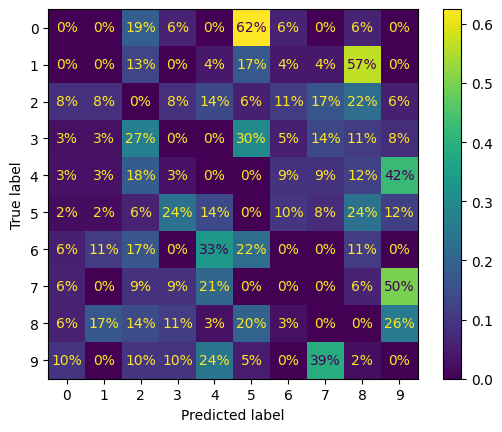

In [58]:
# Confusion Matrices aregenerally not symmetrical!
# If you wanna make the errors stand out more, you can try putting zero weight on the correct predictions.
sample_weight = (y_train_pred != y_train)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, sample_weight=sample_weight, normalize="true", values_format=".0%")
plt.show()

In [59]:
# Be careful how you interpret the percentages in this diagram:
# Remember that we've excluded the correct predictions.

# Analyzing the confusion matrix often gives you insights into ways to improve your classifier.
# You could engineer new features that would help the classifier for example, writting an algorithm to count the number of closed loops
# Or you could preprocess the images (using scikit-image, Pillow, or OpenCV) to make some pattern, such as closed loops, stand out more.
# Analyzing individual errors can also be a good way to gain insights into what your clasifier is doing and why it i failing

cl_a, cl_b = '3', '5'
X_aa = X_train[(y_train == cl_a) & (y_train_pred == cl_a)]
X_ab = X_train[(y_train == cl_a) & (y_train_pred == cl_b)]
X_ba = X_train[(y_train == cl_b) & (y_train_pred == cl_a)]
X_bb = X_train[(y_train == cl_b) & (y_train_pred == cl_b)]
[...] # plot all images in X_ab, X_ab, X_ba, X_bb in a confusion matrix style.



[Ellipsis]

In [60]:
# This task feels simple does not mean that it is:
# SGDClassifier: all it does is assign a weight per class to each pixel, and when it sees a new image it just sum up the weighted pixel intensities
# to get a score for each class.

# This classifier is quite sensitive to image shifting and rotations.
# This may not be easy since it requires predicting the correct rotation of each image.
# A much simpler approach consisits of augmenting the traniing set with slightly shifted and rotated variants of the training images.
# This will force the model to learn to be more tolerant to such variation.
# This is called "data augmentation."

In [61]:
""" Multilabel Classification """

# In some case, you may want your classifier to output multiple classes for each instance.
# 3 Values = 3 outputs [True, False, True]
# Such a classification system that outputs multiple binary tags is called "a multilabel classification system"

import numpy as np
from sklearn.neighbors import KNeighborsClassifier

y_train_large = (y_train >= '7')
y_train_odd = (y_train.astype('int8') % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [62]:
# The code  creates a y_multilabel array containing 2 target labels for each digit image
# KNeighborsClassifier supports multilabel classification (not all classifiers do) and trains this model using the multiple targets array.

knn_clf.predict([some_digit])

array([[False,  True]])

In [63]:
# Measure the F1 score for each individual label (or any other binary classifier metric discussed ealier) then simply compute the average score.

y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9176605556691428

In [64]:
# In particular, If you have many more you may want to give more weigh to the clasifier's score.
# Simple way is to give each label a weight equal to its "support"
# To do this simply set average="weighted" when calling the f1_score() function.

# train one model per label.

# The models can be organized in a chain: When a model makes a prediction, it uses the inout features plus all the predictions of the models that come before it in the chain.

# ClaasifierChain()
#It will use the true labels for training, feeding each model the appropriate labels depending on their position in the chain.
# If you set the cv hyperparameter, it will use cross-validation to get "clean" (out-of-sample) predictions from each trained model for every instance in the training set,
# and These predictions will then be used to train all the models later in the chain.

from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])
chain_clf.predict([some_digit])

array([[0., 1.]])

In [69]:
""" Multioutput Classification """

# It is a generalization of multilabel classification where each label can be multiclass.
# It can have more than 2 possible values.

# Argubly, predicting pixel intensity is more akin to regression than to classification.
# You could even have a system that outputs multiple label per instance, including both class labels and value labels.
import numpy as np

np.random.seed(42)
noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_fold = X_test

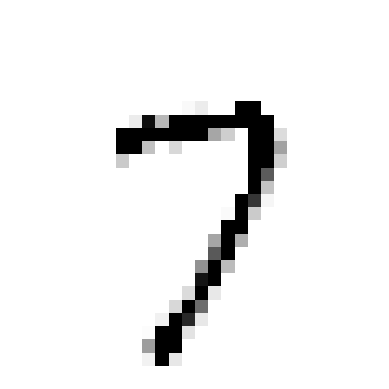

In [70]:
# We're snooping on the test data.
# On the left is the noisy input image, and on the right is the clean targer image.
# Let's trian the classifier and make it clean up this image:

knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[0]])
plot_digit(clean_digit)
plt.show()

In [ ]:
# Looks close enough to the target!

# Summary:
# you know how to select a good metrics for classification tasks, pick the appropriate precision/recall trade-off and compare classifiers.
# You can generally build good classfication systems for a variety of tasks as well.

# The End.